### CIFAR-10 Classification with S4

In [10]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from cifar10_task import CIFAR10Task
from src.train_utils.trainer import Trainer

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [11]:
from src.utils.block_factory import make_s4_block_cfg_ctor

In [12]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "CIFAR10" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 32,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permute": False,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 100,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/cifar10_s4_task",
    "warmup_epochs": 10,
    "patience": 10,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 256,
    "depth": 1,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",
}

args["block_cfg_ctor"] = make_s4_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False

Using MPS


### Training
With the configuration set up, we can now instantiate the `CIFAR10Task` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [13]:
from src.utils.visualization import plot_classification_history as plot_history

In [5]:
task = CIFAR10Task()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


CIFAR-10 Loaders Created:
  Train: 50000 samples, 1562 batches
  Test:  10000 samples, 313 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled


Epoch 026/100 | train 1.0497/0.6298 | val 1.2240/0.5823 | t 361.1s/22.1s | lr 9.24e-04


Epoch 027/100 | train 1.0386/0.6304 | val 1.2605/0.5766 | t 377.0s/24.0s | lr 9.15e-04


saved best model to ./runs/cifar10_s4_task/best.pt
new best acc 0.6008
Epoch 028/100 | train 1.0288/0.6350 | val 1.1678/0.6008 | t 417.8s/26.5s | lr 9.05e-04


...

Epoch 050/100 | train 0.9520/0.6604 | val 1.1953/0.6012 | t 388.3s/22.2s | lr 5.87e-04


Epoch 051/100 | train 0.9572/0.6605 | val 1.1910/0.6027 | t 388.8s/22.2s | lr 5.70e-04


Epoch 052/100 | train 0.9488/0.6626 | val 1.1876/0.6056 | t 402.0s/24.6s | lr 5.52e-04


Epoch 053/100 | train 0.9331/0.6695 | val 1.2346/0.5955 | t 398.6s/21.3s | lr 5.35e-04


Early stopping (patience=10, best=0.6163).
Training history saved to ./runs/cifar10_s4_task/history.json
Done. Best acc=0.6163 @ ./runs/cifar10_s4_task/best.pt


CIFAR-10 Loaders Created:
  Train: 50000 samples, 1562 batches
  Test:  10000 samples, 313 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled
Loaded checkpoint from epoch 43
Val metrics: {'loss': 1.1370926685333251, 'time_s': 21.632991665999725, 'acc': 0.6163}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


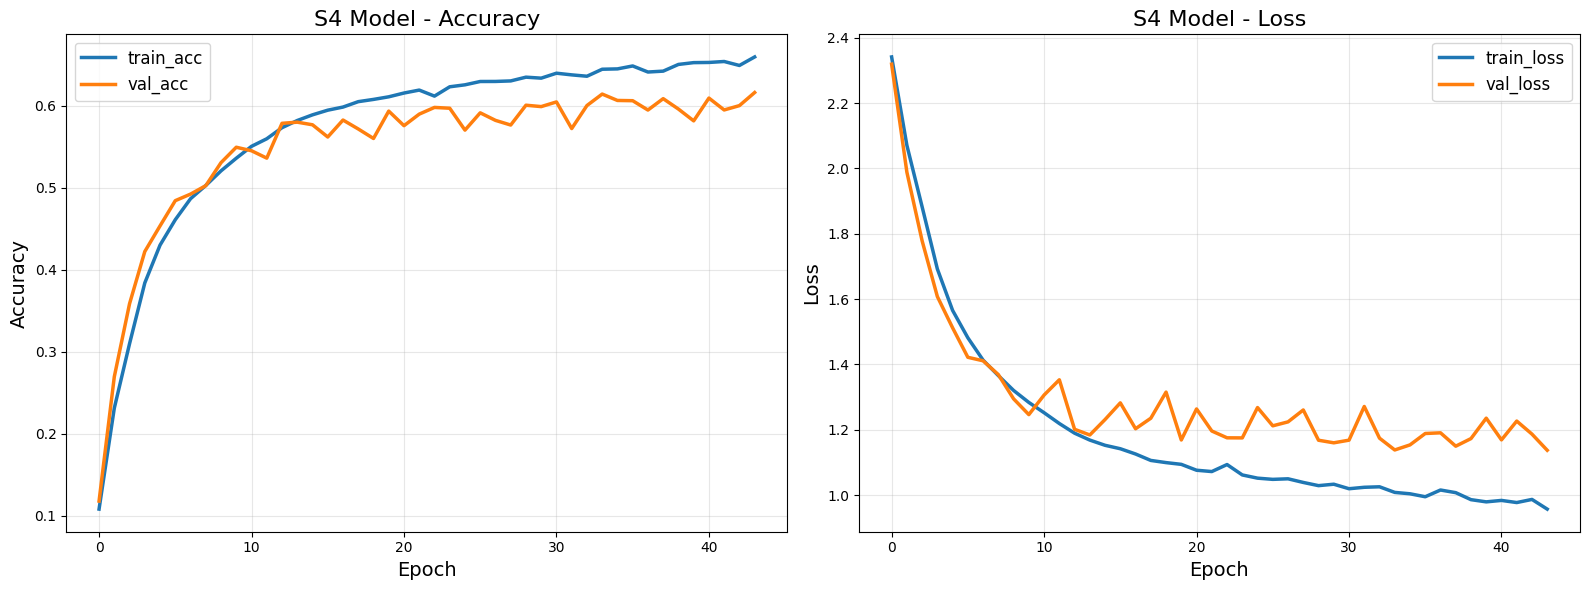

In [14]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=CIFAR10Task(),
)

history = trainer.history

plot_history(history, model_name="S4")

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

CIFAR-10 Loaders Created:
  Train: 50000 samples, 1562 batches
  Test:  10000 samples, 313 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled
Loaded checkpoint from epoch 43
Val metrics: {'loss': 1.1370926685333251, 'time_s': 21.632991665999725, 'acc': 0.6163}
CIFAR-10 Loaders Created:
  Train: 50000 samples, 1562 batches
  Test:  10000 samples, 313 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled

 Test results saved to: runs/cifar10_s4_task/test_results.json

TEST SET RESULTS
   Accuracy: 0.6163 (61.63%)
   Loss: 1.1371
Overall accuracy: 0.6163
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_8                   : 0.791
02. class_6                   : 0.773
03. class_1                   : 0.771
04. class_7                   : 0.706
05. class_9                   : 0.678
06. class_0                   : 0.602
07. class_4                   : 0

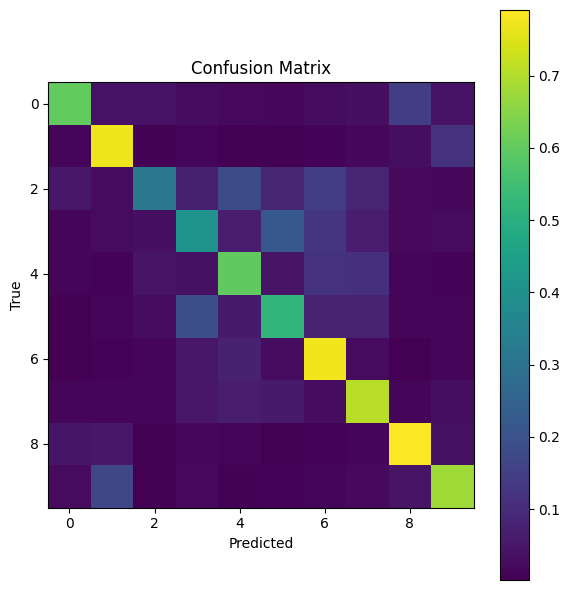

In [15]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model
from src.utils.common import print_model_details

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=CIFAR10Task(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

print_model_details(model=trainer.model)

### Evaluation on different model sizes - equal to LMU

CIFAR-10 Loaders Created:
  Train: 50000 samples, 1562 batches
  Test:  10000 samples, 313 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled
Loaded checkpoint from epoch 30
Val metrics: {'loss': 0.9779198192596436, 'time_s': 3.636907933978364, 'acc': 0.7421}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


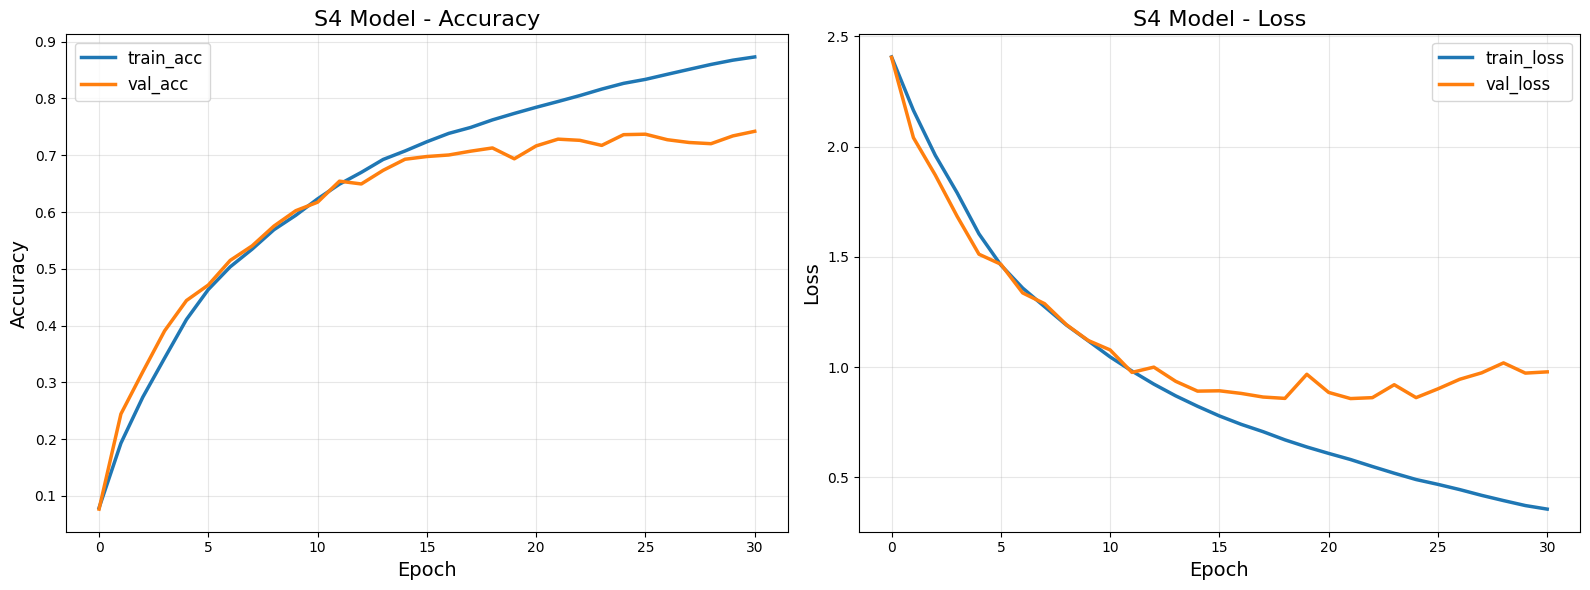

CIFAR-10 Loaders Created:
  Train: 50000 samples, 1562 batches
  Test:  10000 samples, 313 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled
Loaded checkpoint from epoch 30
Val metrics: {'loss': 0.9779198192596436, 'time_s': 3.636907933978364, 'acc': 0.7421}
CIFAR-10 Loaders Created:
  Train: 50000 samples, 1562 batches
  Test:  10000 samples, 313 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled

 Test results saved to: runs/cifar10_s4_task_equal_params/test_results.json

TEST SET RESULTS
   Accuracy: 0.7421 (74.21%)
   Loss: 0.9779
Overall accuracy: 0.7421
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_8                   : 0.879
02. class_9                   : 0.873
03. class_6                   : 0.822
04. class_1                   : 0.814
05. class_7                   : 0.757
06. class_4                   : 0.755
07. class_0          

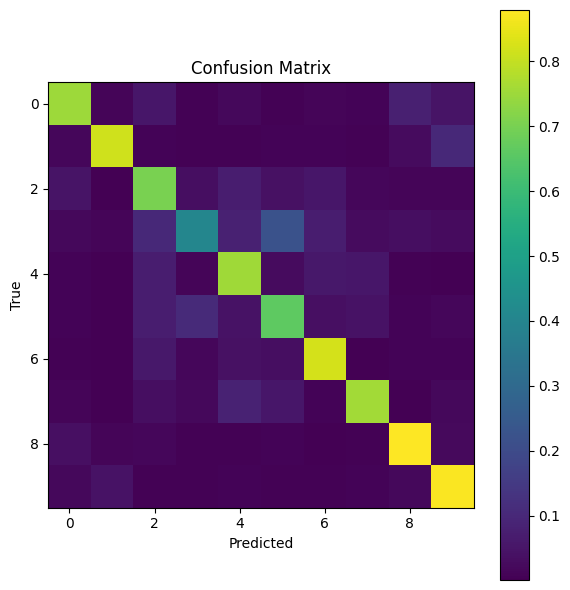

In [16]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model
from src.utils.common import print_model_details
from src.utils.checkpoint import load_trainer_from_checkpoint

equal_params_args = args.copy()
equal_params_args["d_model"] = 152
equal_params_args["depth"] = 4
equal_params_args['save_dir'] = "./runs/cifar10_s4_task_equal_params"

trainer = load_trainer_from_checkpoint(
    checkpoint_path=equal_params_args["save_dir"] + "/best.pt",
    args=equal_params_args,
    task=CIFAR10Task(),
)

plot_history(trainer.history, model_name="S4")

logits_test, labels_test = evaluate_best_model(
    args=equal_params_args,
    task=CIFAR10Task(),
    best_model_path=f"{equal_params_args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

print_model_details(model=trainer.model)

### Changes in dataset size

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/cifar10_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=CIFAR10Task())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="S4")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=CIFAR10Task(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )
